In [1040]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [1041]:
df = df.drop(["id"], axis=1)

In [1042]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [1043]:
df.shape

(920, 15)

In [1044]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [1045]:
nan_features = [feature for feature in df.columns if df[feature].isnull().sum() > 1 ]
nan_features

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [1046]:
# # we need to find relationship between missing values and num

# for feature in nan_features: 
#     data = df.copy()
    
#     # indicates 1 if the observation was missing or zero otherwise
#     data[feature] = np.where(data[feature].isnull(), 1,0)

#     # mean of the SalePrice where the information is missing or present 
#     data.groupby(feature)["num"].sum().plot.bar()
#     plt.title(feature)
#     plt.show()


In [1047]:
df.thal.isnull().sum()

486

In [1048]:
df.ca.isnull().sum()

611

## 0 >> 1 ve fark çok büyük → Eksiklik nadir, bilgi taşımıyor → imputing yeterli.

## 0 ve 1 barları ikisi de büyük veya yakın → Eksiklik önemli, bilgi taşıyor → imputing + dummy feature ekle.

In [1050]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != "O"]
numerical_features

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

In [1051]:
## numerical: discrete and continuous 
discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<25]
discrete_features

['ca', 'num']

In [1052]:
# # relationship between them and saleprice 

# for feature in discrete_features:
#     data = df.copy()
#     data.groupby(feature)["num"].median().plot.bar()
#     plt.xlabel(feature)
#     plt.ylabel("num")
#     plt.title(feature)
#     plt.show()

In [1053]:
continuous_features = [feature for feature in numerical_features if feature not in discrete_features]
continuous_features

['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [1054]:
# for feature in continuous_features:
#     data=df.copy()
#     data[feature].hist(bins=25)
#     plt.xlabel(feature)
#     plt.ylabel("Count")
#     plt.title(feature)
#     plt.show()

Harika, o zaman histogramlarına tek tek bakalım:

İlk histogram (yaş gibi görünen, 20–80 aralığında dağılan feature)

Gayet düzgün, neredeyse normal dağılım gibi.

Outlier pek yok, küçük uçlar var ama sorun çıkarmaz.

Burada direkt standard scaling yeterli.

İkinci histogram (20’den başlayıp 300’e doğru giden, sağa çarpık dağılım)

Bariz sağa çarpıklık (right-skew).

250–300 civarında az ama uç değerler var.

Burada log transform veya Yeo-Johnson uygularsan outlier etkisi azalır, dağılım normale yaklaşır. Sonra scale edebilirsin.

Üçüncü histogram (çoğu değer 0–50 arası, ama 300–400’e kadar uçan feature)

Aşırı uç değerler var.

Çok yoğun 0 civarında yığılma.

Burada ya outlier’ları “winsorize” (örneğin %99 persentile kırpma) yapabilirsin ya da log transform ile dağılımı sıkıştırabilirsin.

Dördüncü histogram (40–250 arası, çan eğrisine yakın)

Gayet doğal, biraz sağa kayık ama büyük outlier yok.

Burada StandardScaler veya RobustScaler rahat çalışır.

Beşinci histogram (0 civarında aşırı yoğunluk, sağa doğru uzun kuyruk)

Aşırı çarpıklık + outlier’lar çok belirgin.

Bu durumda en mantıklı: önce log transform (veya Box-Cox / Yeo-Johnson), sonra scale.

Outlier’ları hiç ele almazsan bile log dönüşümü etkilerini çok azaltır.

Özet:

## 1 ve 4 → direkt scale.

## 2, 3, 5 → önce outlier dönüşümü (log/yeo-johnson ya da winsorize), sonra scale.

## bu işlemlerin hepsi train sette yapılmalı 

In [1056]:
df.oldpeak.unique()

array([ 2.3,  1.5,  2.6,  3.5,  1.4,  0.8,  3.6,  0.6,  3.1,  0.4,  1.3,
        0. ,  0.5,  1.6,  1. ,  1.2,  0.2,  1.8,  3.2,  2.4,  2. ,  2.5,
        2.2,  2.8,  3. ,  3.4,  6.2,  4. ,  5.6,  2.9,  0.1,  2.1,  1.9,
        4.2,  0.9,  1.1,  3.8,  0.7,  0.3,  4.4,  5. ,  nan, -1.1, -1.5,
       -0.1, -2.6, -0.7, -2. , -1. ,  1.7, -0.8, -0.5, -0.9,  3.7])

In [1057]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [1058]:
# categorical variables

categorical_features = [feature for feature in df.columns if df[feature].dtypes=="O"]

In [1059]:
df[categorical_features].head()

,sex,dataset,cp,fbs,restecg,exang,slope,thal
0,Male,Cleveland,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,Male,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,normal
2,Male,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,reversable defect
3,Male,Cleveland,non-anginal,False,normal,False,downsloping,normal
4,Female,Cleveland,atypical angina,False,lv hypertrophy,False,upsloping,normal


In [1060]:
# for feature in categorical_features:
#     data = df.copy()
#     data.groupby(feature)["num"].sum().plot.bar()
#     plt.xlabel(feature)
#     plt.ylabel("num")
#     plt.title(feature)
#     plt.show()

## FEATURE ENGINEERING 
handling missing values 

ca ve thal için sadece imputing yetmez, imputing + dummy

In [1062]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(["num"], axis=1), df.num,test_size=0.33, random_state=0)

In [1063]:
numerical_na_features = [feature for feature in nan_features if df[feature].dtypes != "O"]
numerical_na_features.remove("ca")
numerical_na_features

['trestbps', 'chol', 'thalch', 'oldpeak']

In [1064]:
X_train.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
827,59,Male,VA Long Beach,asymptomatic,124.0,NaN,False,normal,117.0,True,1.0,flat,NaN,NaN
720,63,Male,VA Long Beach,asymptomatic,140.0,260.0,False,st-t abnormality,112.0,True,3.0,flat,NaN,NaN
741,64,Male,VA Long Beach,asymptomatic,120.0,0.0,True,st-t abnormality,106.0,False,2.0,flat,NaN,NaN
17,54,Male,Cleveland,asymptomatic,140.0,239.0,False,normal,160.0,False,1.2,upsloping,0.0,normal
568,53,Male,Hungary,non-anginal,145.0,518.0,False,normal,130.0,False,0.0,NaN,NaN,NaN


In [1065]:
# replacing with numerical missing values 

for feature in numerical_na_features: 
    # we will replace by median since there are outliers 
    median_value = X_train[feature].median()

    # X_train[feature + "nan"] = np.where(X_train[feature].isnull(), 1, 0)
    X_train[feature] = X_train[feature].fillna(median_value)
for feature in numerical_na_features: 
    # we will replace by median since there are outliers 
    median_value = X_test[feature].median()

    # X_train[feature + "nan"] = np.where(X_train[feature].isnull(), 1, 0)
    X_test[feature] = X_test[feature].fillna(median_value)
X_train[numerical_na_features].isnull().sum()

trestbps    0
chol        0
thalch      0
oldpeak     0
dtype: int64

In [1066]:
categorical_features

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [1067]:
categorical_nan_features = [feature for feature in nan_features if df[feature].dtypes == "O"]
categorical_nan_features.remove("thal")

In [1068]:
for feature in categorical_nan_features: 
    X_train[feature] = X_train[feature].fillna(method="ffill")
for feature in categorical_nan_features: 
    X_test[feature] = X_test[feature].fillna(method="ffill").fillna(method="bfill")
X_train[categorical_nan_features].isnull().sum()

C:\Users\atahi\AppData\Local\Temp\ipykernel_8852\89769982.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train[feature] = X_train[feature].fillna(method="ffill")
C:\Users\atahi\AppData\Local\Temp\ipykernel_8852\89769982.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[feature] = X_train[feature].fillna(method="ffill")
C:\Users\atahi\AppData\Local\Temp\ipykernel_8852\89769982.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test[feature] = X_test[feature].fillna(method="ffill").fillna(method="bfill")
C:\Users\atahi\AppData\Local\Temp\ipykernel_8852\89769982.py:4: FutureWarn

fbs        0
restecg    0
exang      0
slope      0
dtype: int64

In [1069]:
for feature in ["ca", "thal"]: 
    X_train[feature + "nan"] = np.where(X_train[feature].isnull(), 1, 0)
    X_test[feature + "nan"] = np.where(X_test[feature].isnull(), 1, 0)
    X_train["ca"] = X_train["ca"].fillna(X_train["ca"].median(numeric_only=True))
    X_test["ca"] = X_test["ca"].fillna(X_test["ca"].median(numeric_only=True))
    X_train["thal"] = X_train["thal"].fillna("Missing")
    X_test["thal"] = X_test["thal"].fillna("Missing")
X_train.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
canan       0
thalnan     0
dtype: int64

In [1070]:
X_train.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,canan,thalnan
827,59,Male,VA Long Beach,asymptomatic,124.0,223.0,False,normal,117.0,True,1.0,flat,0.0,Missing,1,0
720,63,Male,VA Long Beach,asymptomatic,140.0,260.0,False,st-t abnormality,112.0,True,3.0,flat,0.0,Missing,1,0
741,64,Male,VA Long Beach,asymptomatic,120.0,0.0,True,st-t abnormality,106.0,False,2.0,flat,0.0,Missing,1,0
17,54,Male,Cleveland,asymptomatic,140.0,239.0,False,normal,160.0,False,1.2,upsloping,0.0,normal,0,0
568,53,Male,Hungary,non-anginal,145.0,518.0,False,normal,130.0,False,0.0,upsloping,0.0,Missing,1,0


In [1071]:
continuous_features, discrete_features

(['age', 'trestbps', 'chol', 'thalch', 'oldpeak'], ['ca', 'num'])

## FEATURE ENGINEERING

# 1 ve 4 → direkt scale.
# 2, 3, 5 → önce outlier dönüşümü (log/yeo-johnson ya da winsorize), sonra scale.

In [1074]:
from sklearn.preprocessing import PowerTransformer

# sadece seçilen feature'lara uygula
features = ['trestbps', 'chol', 'oldpeak']

pt = PowerTransformer(method='yeo-johnson')  
X_train[features] = pt.fit_transform(X_train[features])
# for feature in [ 'trestbps', 'chol',  'oldpeak']:
#     X_train[feature] = np.log1p(X_train[feature]
X_test[features] = pt.transform(X_test[features])

In [1075]:
X_train.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,canan,thalnan
827,59,Male,VA Long Beach,asymptomatic,-0.409266,0.301507,False,normal,117.0,True,0.332241,flat,0.0,Missing,1,0
720,63,Male,VA Long Beach,asymptomatic,0.514049,0.577314,False,st-t abnormality,112.0,True,1.752485,flat,0.0,Missing,1,0
741,64,Male,VA Long Beach,asymptomatic,-0.670563,-1.930382,True,st-t abnormality,106.0,False,1.122240,flat,0.0,Missing,1,0
17,54,Male,Cleveland,asymptomatic,0.514049,0.422074,False,normal,160.0,False,0.508287,upsloping,0.0,normal,0,0
568,53,Male,Hungary,non-anginal,0.768638,2.294507,False,normal,130.0,False,-0.790228,upsloping,0.0,Missing,1,0


In [1076]:
for feature in categorical_features: 
    labels_ordered = X_train.groupby([feature])["age"].mean().sort_values().index
    labels_ordered = {k:i for i,k in enumerate(labels_ordered, 0)}
    X_train[feature] = X_train[feature].map(labels_ordered)
for feature in categorical_features: 
    labels_ordered = X_test.groupby([feature])["age"].mean().sort_values().index
    labels_ordered = {k:i for i,k in enumerate(labels_ordered, 0)}
    X_test[feature] = X_test[feature].map(labels_ordered)
X_train.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,canan,thalnan
827,59,1,3,2,-0.409266,0.301507,0,0,117.0,1,0.332241,1,0.0,0,1,0
720,63,1,3,2,0.514049,0.577314,0,2,112.0,1,1.752485,1,0.0,0,1,0
741,64,1,3,2,-0.670563,-1.930382,1,2,106.0,0,1.122240,1,0.0,0,1,0
17,54,1,1,2,0.514049,0.422074,0,0,160.0,0,0.508287,0,0.0,1,0,0
568,53,1,0,1,0.768638,2.294507,0,0,130.0,0,-0.790228,0,0.0,0,1,0


In [1077]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[continuous_features])
scaler.transform(X_train[continuous_features])
scaler.transform(X_test[continuous_features])

array([[-2.4785007 ,  1.85714571,  0.40711606,  1.26011056, -0.79022776],
       [ 1.56306979,  0.24443479, -1.93038185, -0.71351798, -0.79022776],
       [-0.88314393, -1.38951118,  0.60652248, -0.23984713,  0.50828719],
       ...,
       [ 0.92492708, -0.04169529, -0.11466144, -0.71351798,  1.75248535],
       [ 0.81856996, -1.38951118, -1.93038185, -1.18718883,  1.12223995],
       [-0.1386441 ,  1.45461157,  1.08081725, -1.73980482,  1.4522873 ]])

In [1078]:
X_train.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,canan,thalnan
827,59,1,3,2,-0.409266,0.301507,0,0,117.0,1,0.332241,1,0.0,0,1,0
720,63,1,3,2,0.514049,0.577314,0,2,112.0,1,1.752485,1,0.0,0,1,0
741,64,1,3,2,-0.670563,-1.930382,1,2,106.0,0,1.122240,1,0.0,0,1,0
17,54,1,1,2,0.514049,0.422074,0,0,160.0,0,0.508287,0,0.0,1,0,0
568,53,1,0,1,0.768638,2.294507,0,0,130.0,0,-0.790228,0,0.0,0,1,0


In [1079]:
X_test.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,canan,thalnan
306,30,0,0,2,1.857146,0.407116,0,1,170.0,0,-0.790228,0,0.0,1,1,0
711,68,1,2,3,0.244435,-1.930382,0,1,120.0,1,-0.790228,0,0.0,3,1,0
298,45,1,1,2,-1.389511,0.606522,0,0,132.0,0,0.508287,1,0.0,3,0,0
466,55,1,0,1,-0.670563,0.278664,0,2,134.0,0,-0.790228,1,0.0,0,1,0
253,51,0,1,1,-0.670563,0.829304,0,2,157.0,0,-0.058313,0,0.0,2,0,0


In [1080]:
# ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
X_train = pd.concat([X_train[["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", 'ca', "thal", "canan", "thalnan"]].reset_index(drop=True),
                 pd.DataFrame(scaler.transform(X_train[continuous_features]),
                 columns=continuous_features)], axis=1)
X_test = pd.concat([X_test[["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", 'ca', "thal", "canan", "thalnan"]].reset_index(drop=True),
                 pd.DataFrame(scaler.transform(X_test[continuous_features]),
                 columns=continuous_features)], axis=1)
X_train.head()

,sex,dataset,cp,fbs,restecg,exang,slope,ca,thal,canan,thalnan,age,trestbps,chol,thalch,oldpeak
0,1,3,2,0,0,1,1,0.0,0,1,0,0.605856,-0.409266,0.301507,-0.831936,0.332241
1,1,3,2,0,2,1,1,0.0,0,1,0,1.031284,0.514049,0.577314,-1.029299,1.752485
2,1,3,2,1,2,0,1,0.0,0,1,0,1.137641,-0.670563,-1.930382,-1.266134,1.122240
3,1,1,2,0,0,0,0,0.0,1,0,0,0.074070,0.514049,0.422074,0.865385,0.508287
4,1,0,1,0,0,0,0,0.0,0,1,0,-0.032287,0.768638,2.294507,-0.318792,-0.790228


In [1081]:
from sklearn.linear_model import Lasso 
from sklearn.feature_selection import SelectFromModel
feature_sel_model = SelectFromModel(Lasso(alpha=0.0005, random_state=0))
feature_sel_model.fit(X_train, y_train)
feature_sel_model.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True])

In [1082]:
from sklearn.feature_selection import VarianceThreshold
var_thres = VarianceThreshold(threshold=0)
var_thres.fit(X_train)
var_thres.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True])

In [1083]:
def correlation(dataset, threshold):
    col_corr = set() #set of all the names of correlated columns 
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i] #getting the name of columns
                col_corr.add(colname)
    return col_corr
corr_features = correlation(X_train, 0.7)
corr_features

set()

In [1084]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info

array([0.04719528, 0.12067056, 0.13220657, 0.04655518, 0.00061283,
       0.08850199, 0.05091767, 0.02030879, 0.09760946, 0.04242016,
       0.        , 0.08114777, 0.00108233, 0.07778824, 0.10422853,
       0.18324951])

In [1085]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

oldpeak     0.183250
cp          0.132207
dataset     0.120671
thalch      0.104229
thal        0.097609
exang       0.088502
age         0.081148
chol        0.077788
slope       0.050918
sex         0.047195
fbs         0.046555
canan       0.042420
ca          0.020309
trestbps    0.001082
restecg     0.000613
thalnan     0.000000
dtype: float64

In [1086]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_train, y_train)

anova_table = pd.DataFrame({'feature': X_train.columns,
                            'F-value': f_values,
                            'p-value': p_values})
print(anova_table.sort_values('p-value'))

     feature    F-value       p-value
2         cp  43.790548  2.488284e-32
1    dataset  40.090818  7.720058e-30
5      exang  37.773160  2.961935e-28
14    thalch  32.705210  9.968105e-25
15   oldpeak  23.867860  2.308715e-18
0        sex  20.543234  6.748531e-16
11       age  20.251474  1.115432e-15
13      chol  15.647392  3.380360e-12
6      slope  11.581303  4.533946e-09
8       thal  11.462680  5.601600e-09
7         ca  11.228856  8.499852e-09
9      canan   7.832855  3.686420e-06
3        fbs   4.973541  5.964154e-04
12  trestbps   3.577182  6.781177e-03
4    restecg   3.215692  1.256405e-02
10   thalnan        NaN           NaN


C:\Users\atahi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\atahi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [1087]:
# drop_columns = ["canan",  "restecg", "fbs" ]
# drop_columns2 = ["canan","restecg", "fbs" ]
# X_train = X_train.drop(drop_columns, axis=1)
# X_test = X_test.drop(drop_columns2, axis=1)

In [1088]:
X_train.head()

,sex,dataset,cp,fbs,restecg,exang,slope,ca,thal,canan,thalnan,age,trestbps,chol,thalch,oldpeak
0,1,3,2,0,0,1,1,0.0,0,1,0,0.605856,-0.409266,0.301507,-0.831936,0.332241
1,1,3,2,0,2,1,1,0.0,0,1,0,1.031284,0.514049,0.577314,-1.029299,1.752485
2,1,3,2,1,2,0,1,0.0,0,1,0,1.137641,-0.670563,-1.930382,-1.266134,1.122240
3,1,1,2,0,0,0,0,0.0,1,0,0,0.074070,0.514049,0.422074,0.865385,0.508287
4,1,0,1,0,0,0,0,0.0,0,1,0,-0.032287,0.768638,2.294507,-0.318792,-0.790228


In [1089]:
X_test

,sex,dataset,cp,fbs,restecg,exang,slope,ca,thal,canan,thalnan,age,trestbps,chol,thalch,oldpeak
0,0,0,2,0,1,0,0,0.0,1,1,0,-2.478501,1.857146,0.407116,1.260111,-0.790228
1,1,2,3,0,1,1,0,0.0,3,1,0,1.563070,0.244435,-1.930382,-0.713518,-0.790228
2,1,1,2,0,0,0,1,0.0,3,0,0,-0.883144,-1.389511,0.606522,-0.239847,0.508287
3,1,0,1,0,2,0,1,0.0,0,1,0,0.180427,-0.670563,0.278664,-0.160902,-0.790228
4,0,1,1,0,2,0,0,0.0,2,0,0,-0.245001,-0.670563,0.829304,0.746967,-0.058313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,1,2,3,0,1,0,1,0.0,3,1,0,0.924927,1.009512,-1.930382,-2.371366,1.122240
300,1,3,3,0,0,1,1,0.0,0,1,0,-1.308572,1.009512,-0.106535,-0.397737,0.753529
301,1,3,3,0,1,1,1,0.0,0,1,0,0.924927,-0.041695,-0.114661,-0.713518,1.752485
302,1,3,3,0,0,1,2,0.0,0,1,0,0.818570,-1.389511,-1.930382,-1.187189,1.122240


In [1090]:
X_test.isnull().sum()

sex         0
dataset     0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          0
thal        0
canan       0
thalnan     0
age         0
trestbps    0
chol        0
thalch      0
oldpeak     0
dtype: int64

In [1091]:
from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(random_state=0)
logr.fit(X_train, y_train)
y_pred = logr.predict(X_test)
logr.score(X_test, y_test)

C:\Users\atahi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5526315789473685

In [1092]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1": make_scorer(f1_score, average="weighted", zero_division=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)

In [1093]:
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

estimators = [HistGradientBoostingClassifier(scoring='recall', random_state=0),
              GradientBoostingClassifier(random_state=0),
              RandomForestClassifier(class_weight='balanced', random_state=0),
              ]

for est in estimators:
    results = cross_validate(est, X_test, y_test, cv=cv, scoring=scoring, return_train_score=True)
    print("Model: ", est.__class__.__name__)
    print("Mean Precision:", results["test_precision"].mean())
    print("Mean Recall:", results["test_recall"].mean())
    print("Mean F1:", results["test_f1"].mean(), f'\n')

Model:  HistGradientBoostingClassifier
Mean Precision: 0.515256392535194
Mean Recall: 0.526120218579235
Mean F1: 0.5160587923163418 

Model:  GradientBoostingClassifier
Mean Precision: 0.5248678843121949
Mean Recall: 0.5393989071038252
Mean F1: 0.5267931639807895 

Model:  RandomForestClassifier
Mean Precision: 0.4989413266386798
Mean Recall: 0.5293989071038252
Mean F1: 0.50719605756605 



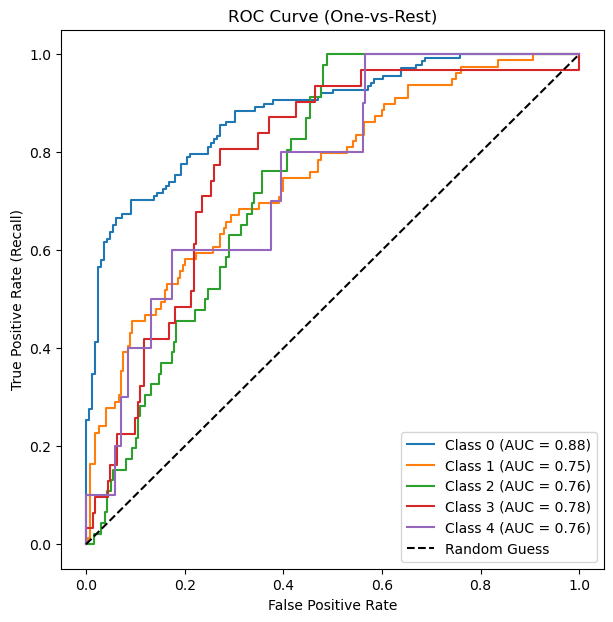

In [1094]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# y_test çok sınıflı → one-hot (binarize)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Modelin olasılık çıktıları
y_prob = logr.predict_proba(X_test)

plt.figure(figsize=(7,7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {auc_score:.2f})")

plt.plot([0,1],[0,1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()


In [1095]:
from sklearn.metrics import roc_auc_score

# Macro ve micro AUC
macro_auc = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")
micro_auc = roc_auc_score(y_test_bin, y_prob, average="micro", multi_class="ovr")

print("Macro AUC:", macro_auc)
print("Micro AUC:", micro_auc)


Macro AUC: 0.7859004106409859
Micro AUC: 0.8463712993421052
